In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# data
X = np.random.randint(1, 11, size=(50,1)).astype(float)

noise = np.random.normal(0, 5, size=(50,1))
y = X**2 + noise


In [2]:
hidden = 3

W1 = np.random.uniform(-1,1,(1,hidden))
b1 = np.zeros((1,hidden))

W2 = np.random.uniform(-1,1,(hidden,1))
b2 = np.zeros((1,1))


In [3]:
def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z > 0).astype(float)


In [4]:
lr = 0.001
epochs = 2000
N = len(X)

losses = []

for epoch in range(epochs):

    # ===== forward =====
    z1 = X @ W1 + b1
    h = relu(z1)

    y_hat = h @ W2 + b2

    # ===== loss =====
    error = y_hat - y
    loss = np.mean(error**2)
    losses.append(loss)

    # ===== backward =====

    dL_dy = (2/N) * error          # dL/dy_hat

    # output layer grads
    dW2 = h.T @ dL_dy
    db2 = np.sum(dL_dy, axis=0, keepdims=True)

    # back to hidden
    dL_dh = dL_dy @ W2.T
    dh_dz1 = relu_derivative(z1)

    dL_dz1 = dL_dh * dh_dz1

    # hidden layer grads
    dW1 = X.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # ===== update =====
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 200 == 0:
        print("Epoch", epoch, "Loss", loss)


Epoch 0 Loss 2551.913680830885
Epoch 200 Loss 1710.6453142349546
Epoch 400 Loss 1378.4860986318856
Epoch 600 Loss 1229.356852931386
Epoch 800 Loss 1162.4024200013168
Epoch 1000 Loss 1132.3419441507901
Epoch 1200 Loss 1118.8457174064924
Epoch 1400 Loss 1112.7863277534736
Epoch 1600 Loss 1110.065848640108
Epoch 1800 Loss 1108.8444374039825


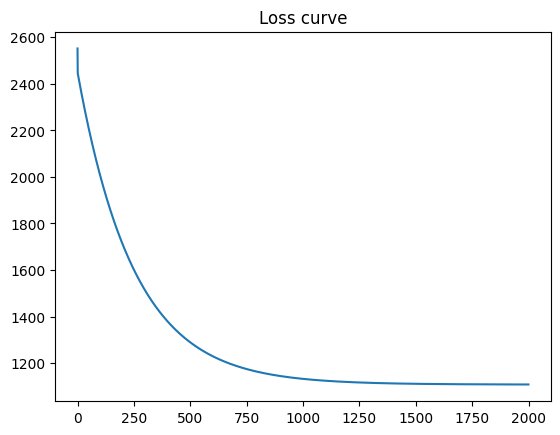

In [5]:
plt.plot(losses)
plt.title("Loss curve")
plt.show()



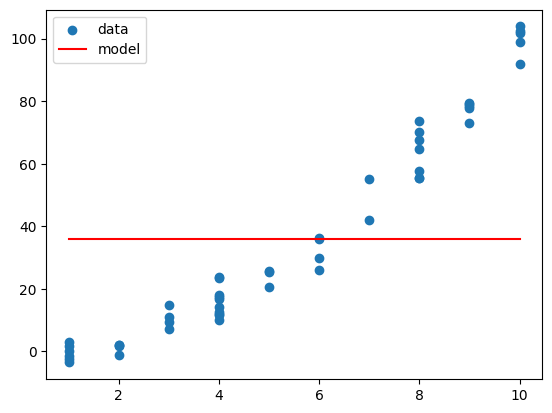

In [6]:
x_test = np.linspace(1,10,100).reshape(-1,1)

z1 = x_test @ W1 + b1
h = relu(z1)
y_pred = h @ W2 + b2

plt.scatter(X,y,label="data")
plt.plot(x_test,y_pred,color="red",label="model")
plt.legend()
plt.show()
